In [25]:
# Import bibliotek

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

In [26]:
import keras
from keras import layers

In [27]:
# Wczytanie danych
# Zbalansowany zbiór danych BRFSS dotyczący wskaźników zdrowia i cukrzycy (klasyfikacja binarna)
df = pd.read_csv(r"C:\Users\mkrol\PycharmProjects\GGSN_labolatory\project01\data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

In [28]:
# Imputacja danych - zastępujemy brakujące wartości (NaN -> średnia arytmetyczna)
# mamy dwa główne podejścia (mean i median)

imputer = SimpleImputer(missing_values = np.nan, strategy='mean') # tworzymy imputację 
df_array = imputer.fit_transform(df) # stosujemy imputację na naszym df i zwracamy nowy array
df = pd.DataFrame(df_array, columns=df.columns) # łączymy nowy array z nazwami kolumn

In [29]:
# Podział danych na cechy (X) i etykiety (y)

X = df.drop(columns=['Diabetes_binary']) 
y = df['Diabetes_binary']

In [30]:
# Podział na dane treningowe i testowe

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    random_state=42, 
    test_size=0.2,
    stratify=y # lepsza stabilność modelu (dba o to, żeby proporcje w zbiorze testowych i treningowym były podobne)
    
)

In [31]:
# Skalowanie danych, sprowadzenie danych do wspólnej skali

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Dopasowanie skalera do danych treningowych i ich transformacja
X_test_scaled = scaler.transform(X_test) # Transformacja danych testowych na podstawie parametrów ze zbioru treningowego


In [32]:
# LightXGM - algorytm oparty na drzewach decyzyjnych.
# Dobre dla danych tabelarycznych i małych/średnich zbiorów
# Przy wybieraniu num_leaves posługuję się zasadą kciuka: num_leaves = 0,6 * (2^max_depth)
model_1 = lgb.LGBMClassifier(
    n_estimators=200, # liczba drzew
    learning_rate=0.05,
    max_depth=10, # maksymalna głębokość (2^10 maksymalnie liści)
    num_leaves=615, # liczba liści
    random_state=42,
    n_jobs=-1, # użyj wszystkich rdzeni procesora
    verbose=-1 # wyłącz komunikaty o działaniu
    # unbalanced=True # jeżeli zbiór jest niezbalansowany
)

# XGBoost - podobny model do LightXGM, starszy, wolniejszy, ale za to bardziej dokładny, odporny na przeuczenie
model_2 = xgb.XGBClassifier(
    n_estimators=200, #liczba drzew      
    learning_rate=0.05,      
    max_depth=6, # maksymalna głębokość (2^10 maksymalnie liści)          
    subsample=0.8, # nowe drzewo jest buduowane na 80% losowo     
    eval_metric='logloss', # metryka do sprawdzania jak dobrze idzie modelowi
    random_state=42,
    n_jobs=-1 # wykorzystaj wszystkie rdzenie procesora
)
# CatBoost - bardzo dobrze radzi sobie z danymi kategoralnymi
model_3 = CatBoostClassifier(
    iterations=500, # liczba drzew
    learning_rate=0.05,
    depth=6, # maksymalna glebokosc
    loss_function='Logloss', # funkcja straty
    eval_metric='AUC', # metryka do monitorowania 
    random_seed=42,
    verbose=0
)

# RandomForest - opiera się na metodzie "Bagging"
model_4 = RandomForestClassifier(
    n_estimators=200, # liczba drzew
    max_depth=None, # drzewa mogą rosnąć do momentu aż nie osiągnie jednego z dwóch stanów
    min_samples_leaf=2, # minimalna liczba obserwacji na liściu
    random_state=42,
    n_jobs=-1 # wykorzystaj wszystkie rdzenie procesora
)

# SVC - szuka optymalnej granicy (hiperpłaszczyzny) między klasami
# Bardzo skuteczny w mniejszych zbiorach, ale przy dużych danych (np. >50k wierszy) może być bardzo powolny
model_5 = SVC(
    kernel='rbf', # jądro gaussowskie, pozwala wyznaczać nieliniowe granice
    C=1.0, # parametr regularyzacji (siła kary za błędy)
    probability=True, # pozwala na uzyskanie wyników prawdopodobieństwa (potrzebne do AUC)
    random_state=42
)

# KNN - klasyfikuje na podstawie "głosowania" najbliższych sąsiadów w przestrzeni danych
# Prosty i intuicyjny, ale wymaga przeskalowanych danych (np. StandardScaler) i dużej pamięci RAM
model_6 = KNeighborsClassifier(n_neighbors=7)

# ANN - prosta sztuczna sieć neuronowa (płytka)
# Dobra do wykrywania nieliniowych zależności przy umiarkowanej liczbie danych
model_7 = tf.keras.Sequential([  # Poprawiłem literówkę: Sequential
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1], )), # Dynamiczne pobranie liczby cech
    layers.Dense(32, activation='relu'), # warstwa ukryta
    layers.Dense(1, activation='sigmoid') # wyjście: prawdopodobieństwo 0-1
])

# DNN - głęboka sieć neuronowa (Deep Neural Network)
# Składa się z wielu warstw, co pozwala na hierarchiczne rozumienie danych
model_8 = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# TabNet - architektura Deep Learning zaprojektowana specjalnie pod tabele (Google Cloud AI)
# Wykorzystuje mechanizm atencji, aby "skupiać się" na najważniejszych cechach podobnie jak drzewa decyzyjne
model_9 = TabNetClassifier(
    n_d=8, # szerokość warstwy decyzyjnej
    n_a=8, # szerokość warstwy atencji
    n_steps=3, # liczba kroków architektury
    verbose=0 # wyciszenie komunikatów treningu
)

C:\Users\mkrol\PycharmProjects\GGSN_labolatory\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
print("Trenowanie modelu LightXGM...")
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)
print("Trenowanie skończone...")

Trenowanie modelu LightXGM...
Trenowanie skończone...


In [34]:
print("Trenowanie modelu XGBoost...")
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)
print("Trenowanie skończone...")

Trenowanie modelu XGBoost...
Trenowanie skończone...


In [35]:
print("Trenowanie modelu CatBoost...")
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)
print("Trenowanie skończone...")

Trenowanie modelu CatBoost...
Trenowanie skończone...


In [36]:
print("Trenowanie modelu RandomForest...")
model_4.fit(X_train,y_train)
y_pred_4 = model_4.predict(X_test)
print("Trenowanie skończone...")

Trenowanie modelu RandomForest...
Trenowanie skończone...


In [37]:
print("Trenowanie modelu SVM...")
model_5.fit(X_train,y_train)
y_pred_5 = model_4.predict(X_test)
print("Trenowanie skończone...")

Trenowanie modelu SVM...
Trenowanie skończone...


In [38]:
print("Trenowanie modelu KNN...")
model_6.fit(X_train,y_train)
y_pred_6 = model_4.predict(X_test)
print("Trenowanie skończone...")

Trenowanie modelu KNN...
Trenowanie skończone...


In [40]:
print("Trenowanie modelu ANN...")
model_7.compile(
    optimizer='adam',                # najpopularniejszy "silnik" do nauki
    loss='binary_crossentropy',      # standard dla klasyfikacji Tak/Nie
    metrics=['accuracy']             # chcemy widzieć dokładność w trakcie nauki
)
# epochs=20 oznacza, że model przejdzie przez wszystkie dane 20 razy
model_7.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)
# Musimy zamienić prawdopodobieństwa na 0 lub 1 (próg 0.5)
y_pred_7_probs = model_7.predict(X_test)
y_pred_7 = (y_pred_7_probs > 0.5).astype("int32")
print("Trenowanie skończone...")

Trenowanie modelu ANN...
Epoch 1/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 3s 886us/step - accuracy: 0.7248 - loss: 0.5456
Epoch 2/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 2s 895us/step - accuracy: 0.7395 - loss: 0.5233
Epoch 3/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 2s 880us/step - accuracy: 0.7427 - loss: 0.5200
Epoch 4/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 2s 912us/step - accuracy: 0.7431 - loss: 0.5165
Epoch 5/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 2s 875us/step - accuracy: 0.7446 - loss: 0.5137
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step
Trenowanie skończone...


In [50]:
print("Trenowanie modelu ANN...")
model_8.compile(
    optimizer='adam',                # najpopularniejszy "silnik" do nauki
    loss='binary_crossentropy',      # standard dla klasyfikacji Tak/Nie
    metrics=['accuracy']             # chcemy widzieć dokładność w trakcie nauki
)
# epochs=20 oznacza, że model przejdzie przez wszystkie dane 20 razy
model_8.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)
# Musimy zamienić prawdopodobieństwa na 0 lub 1 (próg 0.5)
y_pred_8_probs = model_8.predict(X_test)
y_pred_8 = (y_pred_7_probs > 0.5).astype("int32")
print("Trenowanie skończone...")

Trenowanie modelu ANN...
Epoch 1/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7484 - loss: 0.5099
Epoch 2/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7496 - loss: 0.5087
Epoch 3/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7479 - loss: 0.5083
Epoch 4/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7499 - loss: 0.5073
Epoch 5/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7506 - loss: 0.5063
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step
Trenowanie skończone...


In [52]:
print("Trenowanie modelu TabNet...")

# Zakładamy, że X_train i y_train to DataFrame/Series
model_9.fit(
    X_train=X_train.values, 
    y_train=y_train.values.flatten(),
    eval_set=[(X_test.values, y_test.values.flatten())],
    eval_name=['test'],
    eval_metric=['accuracy'], 
    max_epochs=10,             # nieco więcej dla lepszego wyniku
    patience=7,                # automatyczne zatrzymanie
    batch_size=1024,           
    virtual_batch_size=128     
)

# Przy predykcji też warto podać .values
y_pred_9 = model_9.predict(X_test.values)

print("Trenowanie skończone...")

Trenowanie modelu TabNet...
Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_test_accuracy = 0.74998


C:\Users\mkrol\PycharmProjects\GGSN_labolatory\venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Trenowanie skończone...


In [53]:
models = ['LightXGM', 'XGBoost', 'CatBoost', 'RandomForest', 'SVM', 'KNN', 'ANN', 'DNN', 'TabNet']
y_predicted = [y_pred_1, y_pred_2, y_pred_3, y_pred_4, y_pred_5, y_pred_6, y_pred_7, y_pred_8, y_pred_9]

In [54]:
for y_p, model in zip(y_predicted, models):
    acc = accuracy_score(y_test, y_p)
    print(f'[{model}] Accuracy: {acc}')
print()
for y_p, model in zip(y_predicted, models):
    prec = precision_score(y_test, y_p)
    print(f'[{model}] Precision: {prec}')
print()
for y_p, model in zip(y_predicted, models):
    recall = recall_score(y_test, y_p)
    print(f'[{model}] Recall: {recall}')
print()
for y_p, model in zip(y_predicted, models):
    precision = precision_score(y_test, y_p)
    recall = recall_score(y_test, y_p)
    f1 = 2 * (precision * recall) / (precision + recall)
    print(f'[{model}] F1: {f1}')
print()
for y_p, model in zip(y_predicted, models):
    auc = roc_auc_score(y_test, y_p)
    print(f'[{model}] AUC: {auc}')
print()

[LightXGM] Accuracy: 0.7458094631869298
[XGBoost] Accuracy: 0.7523870146403565
[CatBoost] Accuracy: 0.7524577410000707
[RandomForest] Accuracy: 0.7443949359926445
[SVM] Accuracy: 0.7443949359926445
[KNN] Accuracy: 0.7443949359926445
[ANN] Accuracy: 0.7495579602517859
[DNN] Accuracy: 0.7495579602517859
[TabNet] Accuracy: 0.7499823184100715

[LightXGM] Precision: 0.7271538763237024
[XGBoost] Precision: 0.731028231028231
[CatBoost] Precision: 0.7314226429775645
[RandomForest] Precision: 0.7259055838891069
[SVM] Precision: 0.7259055838891069
[KNN] Precision: 0.7259055838891069
[ANN] Precision: 0.7263279445727483
[DNN] Precision: 0.7263279445727483
[TabNet] Precision: 0.7254977029096478

[LightXGM] Recall: 0.7868156740698826
[XGBoost] Recall: 0.7985570802093648
[CatBoost] Recall: 0.7978497665865044
[RandomForest] Recall: 0.7852595840995897
[SVM] Recall: 0.7852595840995897
[KNN] Recall: 0.7852595840995897
[ANN] Recall: 0.800820483802518
[DNN] Recall: 0.800820483802518
[TabNet] Recall: 0.8042

In [55]:
def calc_metrics(y_t=y_test, y_p=0):
    accuracy = accuracy_score(y_t, y_p)
    precision = precision_score(y_t, y_p)
    recall = recall_score(y_t, y_p)
    f1 = 2 * (precision * recall) / (precision + recall)
    auc = roc_auc_score(y_t, y_p)
    
    print("Accuracy: ", accuracy)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1: ", f1)
    print("AUC Score: ",  auc)

In [56]:
def draw_plots(y_t=y_test, y_p=0):
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(cm, annot=True)
    plt.xlabel('Przewidywanie')
    plt.ylabel('Rzeczywistość')
    plt.title('Mapa ciepła macierzy konfucji')
    plt.show()    
    
    precision, recall, thresholds = precision_recall_curve(y_t, y_p)
    ap = average_precision_score(y_test, y_pred_1)
    plt.plot(recall, precision, label=f'AP = {ap:.2f}', color='red')
    plt.xlabel('Recall (Czułość)')
    plt.ylabel('Precision (Precyzja)')
    plt.title('Krzywa Precision-Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

Obliczenia dla modelu 1
Accuracy:  0.7458094631869298
Precision:  0.7271538763237024
Recall:  0.7868156740698826
F1:  0.7558092132083163
AUC Score:  0.7458123632018437


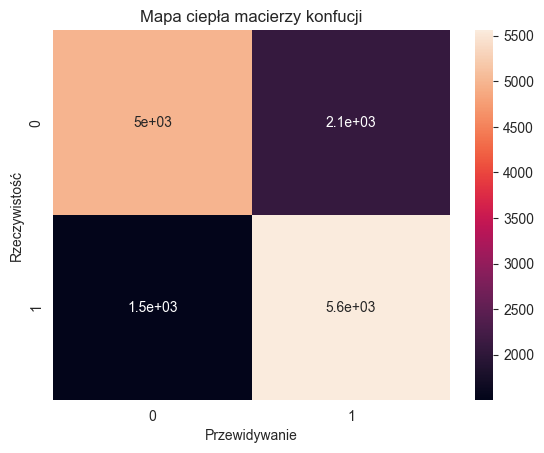

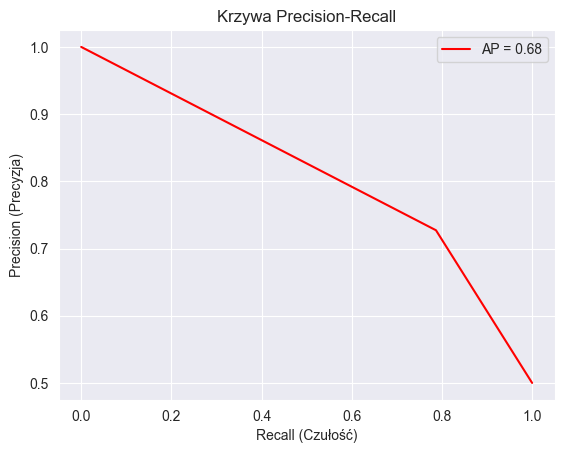

In [57]:
print("Obliczenia dla modelu 1")
calc_metrics(y_test, y_pred_1)
draw_plots(y_test, y_pred_1)

Obliczenia dla modelu 2
Accuracy:  0.7523870146403565
Precision:  0.731028231028231
Recall:  0.7985570802093648
F1:  0.7633020079778244
AUC Score:  0.7523902798500854


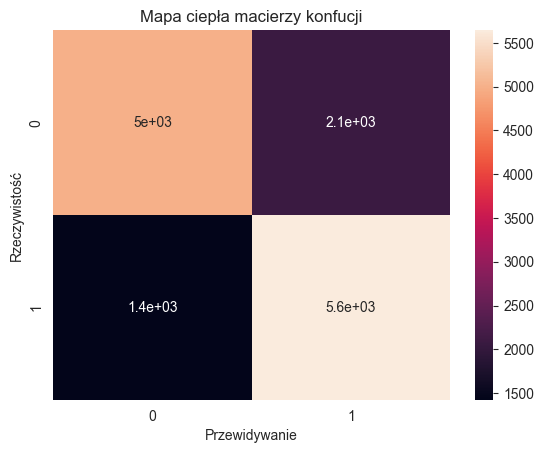

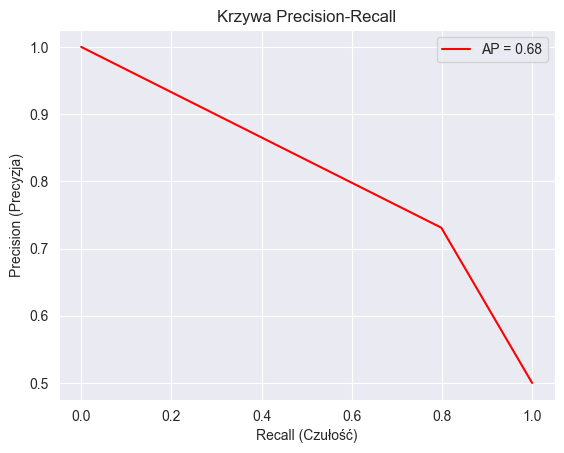

In [58]:
print("Obliczenia dla modelu 2")
calc_metrics(y_test, y_pred_2)
draw_plots(y_test, y_pred_2)

Obliczenia dla modelu 3
Accuracy:  0.7524577410000707
Precision:  0.7314226429775645
Recall:  0.7978497665865044
F1:  0.7631935047361299
AUC Score:  0.7524609511857556


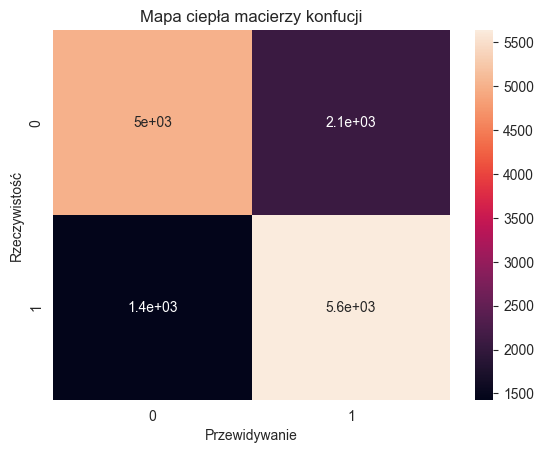

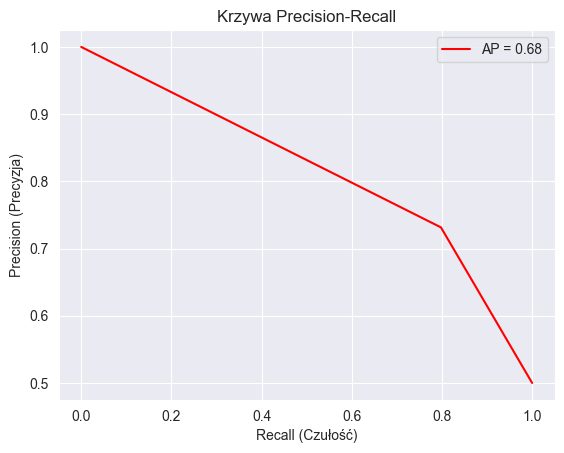

In [59]:
print("Obliczenia dla modelu 3")
calc_metrics(y_test, y_pred_3)
draw_plots(y_test, y_pred_3)

Obliczenia dla modelu 4
Accuracy:  0.7443949359926445
Precision:  0.7259055838891069
Recall:  0.7852595840995897
F1:  0.7544169611307421
AUC Score:  0.7443978259960466


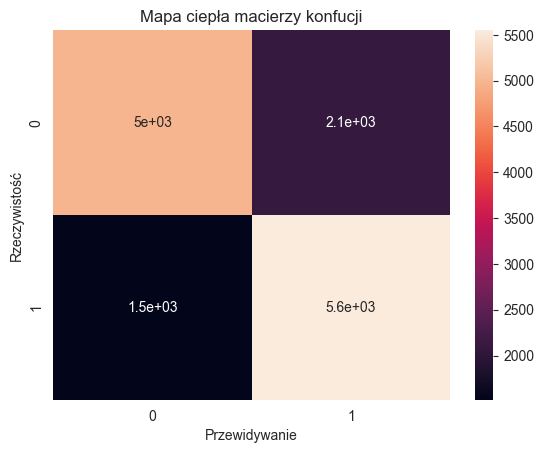

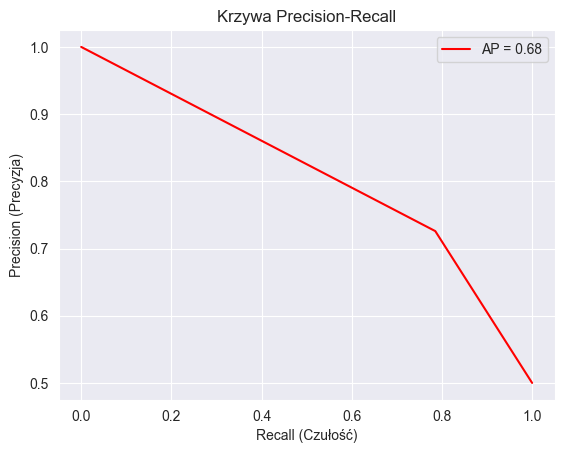

In [60]:
print("Obliczenia dla modelu 4")
calc_metrics(y_test, y_pred_4)
draw_plots(y_test, y_pred_4)

Obliczenia dla modelu 5
Accuracy:  0.7443949359926445
Precision:  0.7259055838891069
Recall:  0.7852595840995897
F1:  0.7544169611307421
AUC Score:  0.7443978259960466


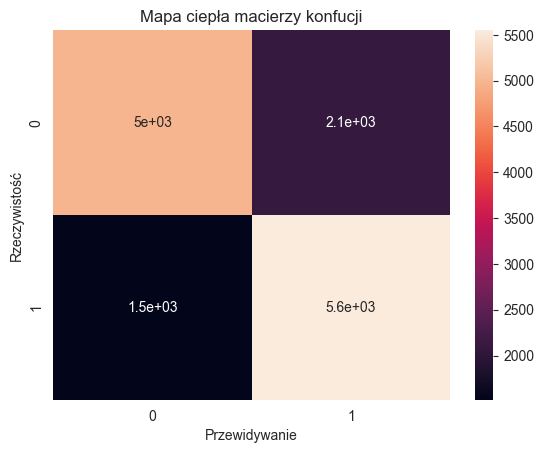

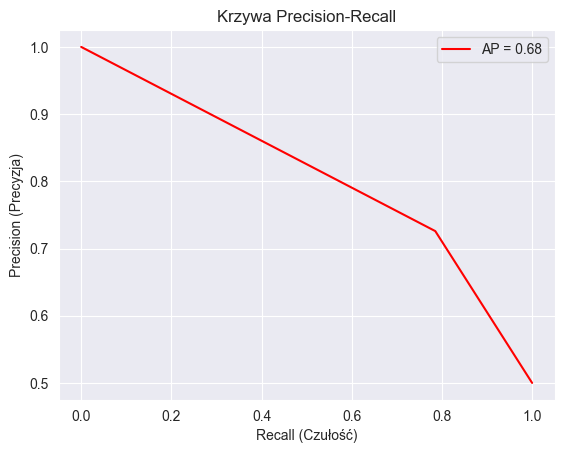

In [61]:
print("Obliczenia dla modelu 5")
calc_metrics(y_test, y_pred_5)
draw_plots(y_test, y_pred_5)

Obliczenia dla modelu 6
Accuracy:  0.7443949359926445
Precision:  0.7259055838891069
Recall:  0.7852595840995897
F1:  0.7544169611307421
AUC Score:  0.7443978259960466


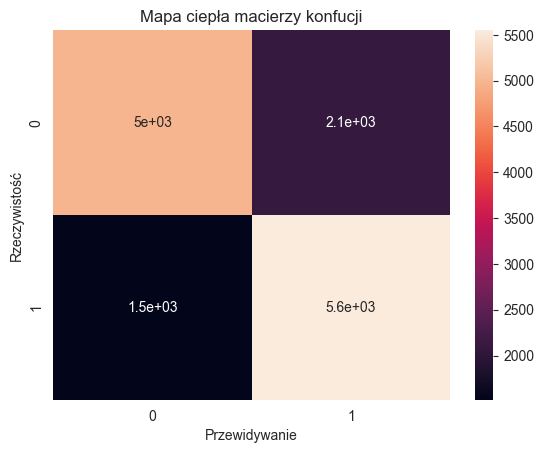

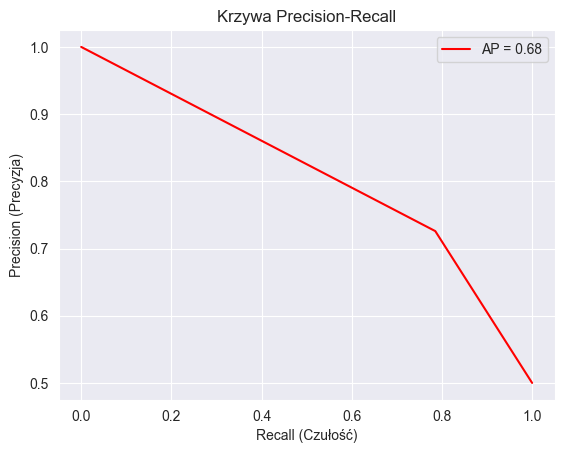

In [62]:
print("Obliczenia dla modelu 6")
calc_metrics(y_test, y_pred_6)
draw_plots(y_test, y_pred_6)

Obliczenia dla modelu 7
Accuracy:  0.7495579602517859
Precision:  0.7263279445727483
Recall:  0.800820483802518
F1:  0.7617573841081882
AUC Score:  0.7495615856070582


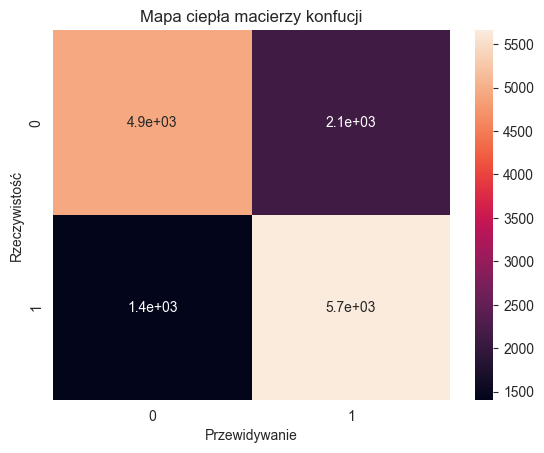

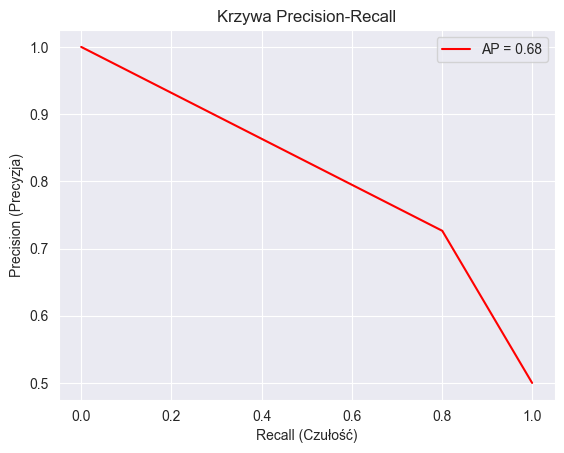

In [63]:
print("Obliczenia dla modelu 7")
calc_metrics(y_test, y_pred_7)
draw_plots(y_test, y_pred_7)

Obliczenia dla modelu 8
Accuracy:  0.7495579602517859
Precision:  0.7263279445727483
Recall:  0.800820483802518
F1:  0.7617573841081882
AUC Score:  0.7495615856070582


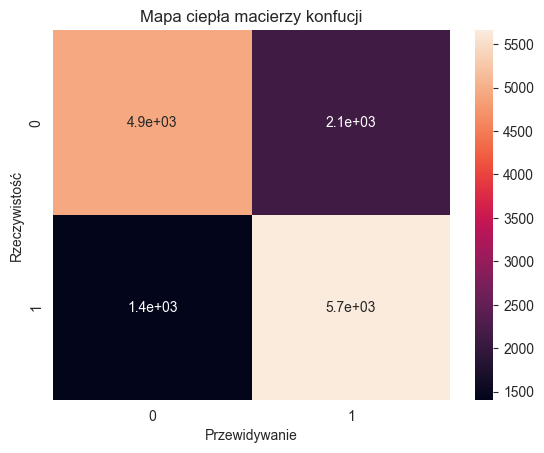

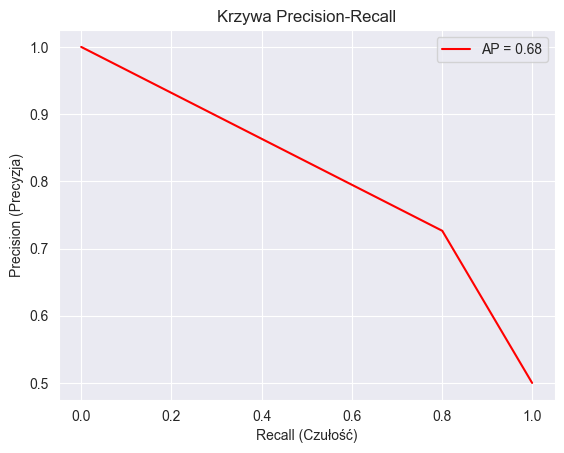

In [64]:
print("Obliczenia dla modelu 8")
calc_metrics(y_test, y_pred_8)
draw_plots(y_test, y_pred_8)

Obliczenia dla modelu 9
Accuracy:  0.7499823184100715
Precision:  0.7254977029096478
Recall:  0.8042155891922479
F1:  0.762831264676283
AUC Score:  0.7499861538606217


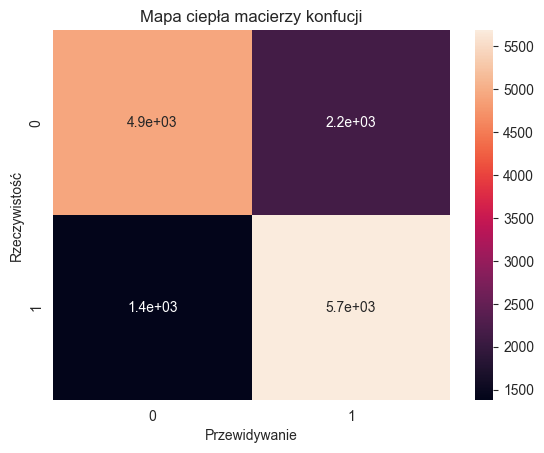

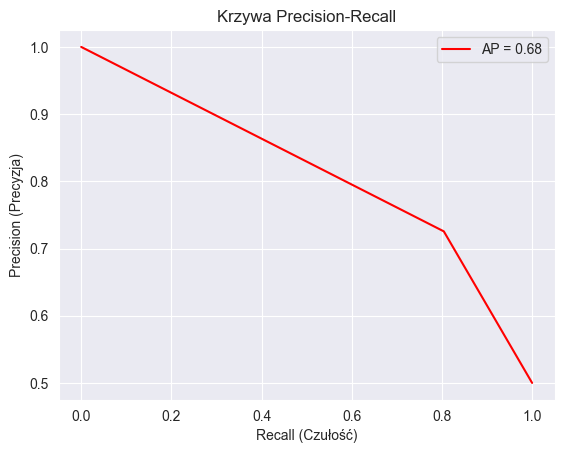

In [65]:
print("Obliczenia dla modelu 9")
calc_metrics(y_test, y_pred_9)
draw_plots(y_test, y_pred_9)

In [ ]:
# Optymalizacja dla RandomForest
from sklearn.model_selection import RandomizedSearchCV

# Tworzymy parametry które będziemy sprawdzać
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500, 1000, 2000],  # liczba drzew
    'max_depth': [None, 5, 10, 15, 20, 30, 40, 50],         # głębokość (None = do oporu)
    'min_samples_split': [2, 3, 4, 5, 8, 10, 15],           # ile próbek, by podzielić węzeł
    'min_samples_leaf': [1, 2, 4,5 ],                       # ile próbek musi zostać na liściu
    'max_features': ['sqrt', 'log2'],                       # ile cech brać pod uwagę przy podziale
    'bootstrap': [True, False]                              # czy losować ze zwracaniem
}

# Tworzymy obiekt wyszukiwania
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,       # oznacza, że sprawdzamy 10 losowych kombinacji
    cv=3,            # dzielimy dane na 3 części
    verbose=0, 
    random_state=42, 
    n_jobs=1,       # użyj wszystkich rdzeni
    scoring='accuracy'
)

rf_random.fit(X_train, y_train)
print("Najlepsze parametry:", rf_random.best_params_)
